In [1]:
import socket

ESP32_IP = "192.168.2.110"  # Change this to ESP32's IP
PORT = 12345  # Same as in ESP32 script

def move_to_esp32(pan, tilt):
    """Send move command to ESP32 via Wi-Fi and read the response."""
    command = f"MOVE:{pan},{tilt}\n"

    try:
        # Connect to ESP32
        esp_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        esp_socket.connect((ESP32_IP, PORT))
        esp_socket.sendall(command.encode())  # Send command

        # Wait for and print ESP32's response
        response = esp_socket.recv(1024).decode().strip()
        print("ESP32 Response:", response)

        esp_socket.close()
    except Exception as e:
        print("Connection error:", str(e))

# Example Usage
# move_to_esp32(30, -20)  # Moves PAN to 30°, TILT to -20°
# move_to_esp32(-45, 45)  # Moves PAN to -45°, TILT to 45°


In [2]:
move_to_esp32(0,0)

ESP32 Response: Moved to PAN=0, TILT=0


In [64]:
import time
import pickle

In [65]:
def unPickle(filename):
    '''
    to shorten 3 lines into 1 line
    '''
    with open(filename,'rb') as f:
        output = pickle.load(f)
    f.close()
    return output

def makePickle(filename,data):
    with open(filename,'wb') as f:
        pickle.dump(data,f)
    f.close()

In [66]:
# import seabreeze (use 'pyseabreeze')
import seabreeze.spectrometers as sb

import os
import math
import numpy as np
import matplotlib.pyplot as plt
import time
import datetime

# set graphics to be plotted in the notebook
%matplotlib inline 

devices = sb.list_devices()
print (devices)

[<SeaBreezeDevice STS:S03615>]


In [67]:
spec = sb.Spectrometer.from_serial_number("S03615")#STS-UV-L-100-400-SMA
# serial number
print (spec.serial_number)
# model
print (spec.model)
# number of pixels (as returned by seabreeze)
print (spec.pixels)
# set the integration time in microseconds
spec.integration_time_micros(400000)
time.sleep(2)

SeaBreezeError: Device already opened.

In [69]:
move_to_esp32(60,20)

ESP32 Response: Moved to PAN=60, TILT=20


In [80]:
#set integration time
micro_time=.02*1e6 # us
spec.integration_time_micros(micro_time)
# load dark noise
#dark_ = np.load(f'../../telescope/data/darkNoise/darkNoise_{micro_time/1e3}ms.npy')

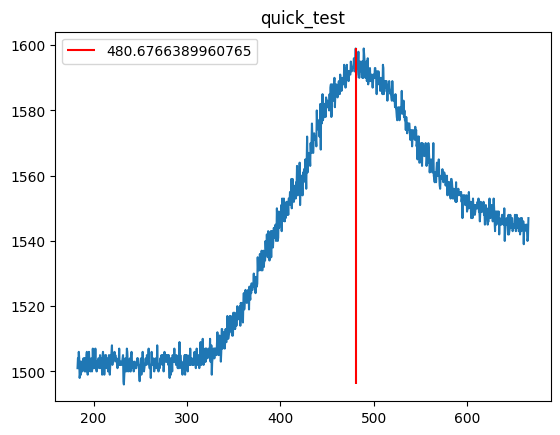

In [81]:
# move_to_esp32(0,-20) # .1 s is enough
nm,ints = spec.spectrum()
plt.plot(nm,ints)
# plt.plot(nm,ints-dark_)
plt.vlines(nm[np.argmax(ints)],np.min(ints),np.max(ints),color='r',label=nm[np.argmax(ints)])
plt.title('quick_test'.format(micro_time/1e3))
# plt.ylim(np.min(ints),np.max(ints))
plt.legend()

## how to determine integration time

In [82]:
h_left = 60
h_right = -20
stepsize_h = 2

h_steps = (np.abs(h_left)+np.abs(h_right))//stepsize_h

v_top = 30
v_threshold = -20
v_down = -20
stepsize_top=2
stepsize_down=2
v_steps = np.abs(v_top-v_threshold)//stepsize_top+np.abs(v_threshold-v_down)//stepsize_down

sleep_time=.4

In [89]:
# Create dictionary
params_dict = {
    "h_left": h_left,
    "h_right": h_right,
    "stepsize_h": stepsize_h,
    "h_steps": int(h_steps),  # Convert to int for clean output

    "v_top": v_top,
    "v_threshold": v_threshold,
    "v_down": v_down,
    "stepsize_top": stepsize_top,
    "stepsize_down": stepsize_down,
    "v_steps": int(v_steps),  # Convert to int for clean output

    "micro_time": micro_time,
    "micro_time_down": None,
    "sleep_time":sleep_time,
    "top_dark_":None,
    "down_dark_":None,
    'weather':'before sunrise',
    'cmt':'morning testing,rain,balcony, no visible sun'
}

In [ ]:
micro_time_MAX= 2 * 1e6
micro_time = .02*1e6
spec.integration_time_micros(micro_time)
while micro_time<= micro_time_MAX:
    ## first part of ONE WHOLE SCAN: determine integration time
    move_to_esp32(h_left,v_top)
    nm,ints = spec.spectrum()
    if np.min(ints)/np.max(ints)>.2:
        micro_time_down = .5*1e6 #micro_time*10
        ## start scan the inital vertical to find the v_threshold
        ## assume v_threshold == -20
        ## start scanning
        output = np.zeros((v_steps+1,h_steps+1,1024))
        print(f'start :{datetime.datetime.now()}')
        start_t = str(datetime.datetime.now())[:19].replace('-','_').replace(':','_').replace(' ','_')
        params_dict['start_t'] = start_t

        print('start at: ',datetime.datetime.now())
        params_dict['scan_pattern']='ul_ll_ur_lr'
        for hh,pan_ in enumerate(range(h_left,h_right-stepsize_h,-stepsize_h)):
            for vv,tilt_ in enumerate(range(v_top,v_down-stepsize_top,-stepsize_top)):
                move_to_esp32(pan_,tilt_)
                if tilt_<v_threshold:
                    spec.integration_time_micros(micro_time_down)
                    
                time.sleep(sleep_time)
                _,output[vv,hh] = spec.spectrum()
        print('finished at: ',datetime.datetime.now())
        
        end_t = str(datetime.datetime.now())[:19].replace('-','_').replace(':','_').replace(' ','_')
        params_dict['raw_record'] = output
        params_dict['end_t'] = end_t
        makePickle(f'./{end_t}.pkl',params_dict)
        break
    else:
        micro_time = micro_time+.1*1e6
        params_dict['micro_time']=micro_time
        spec.integration_time_micros(micro_time)
        print(f'new integration time {micro_time}')
print(f'integration time {micro_time/1e6} s')

ESP32 Response: Moved to PAN=60, TILT=30
start :2025-02-27 07:29:28.003529
start at:  2025-02-27 07:29:28.003656
ESP32 Response: Moved to PAN=60, TILT=30
ESP32 Response: Moved to PAN=60, TILT=28
ESP32 Response: Moved to PAN=60, TILT=26
ESP32 Response: Moved to PAN=60, TILT=24
ESP32 Response: Moved to PAN=60, TILT=22
ESP32 Response: Moved to PAN=60, TILT=20
ESP32 Response: Moved to PAN=60, TILT=18
ESP32 Response: Moved to PAN=60, TILT=16
ESP32 Response: Moved to PAN=60, TILT=14
ESP32 Response: Moved to PAN=60, TILT=12
ESP32 Response: Moved to PAN=60, TILT=10
ESP32 Response: Moved to PAN=60, TILT=8
ESP32 Response: Moved to PAN=60, TILT=6
ESP32 Response: Moved to PAN=60, TILT=4
ESP32 Response: Moved to PAN=60, TILT=2
ESP32 Response: Moved to PAN=60, TILT=0
ESP32 Response: Moved to PAN=60, TILT=-2
ESP32 Response: Moved to PAN=60, TILT=-4
ESP32 Response: Moved to PAN=60, TILT=-6
ESP32 Response: Moved to PAN=60, TILT=-8
ESP32 Response: Moved to PAN=60, TILT=-10
ESP32 Response: Moved to PAN=6

In [85]:
for hh,pan_ in enumerate(range(h_left,h_right,-stepsize_h)):
    print(hh,pan_)

0 60
1 58
2 56
3 54
4 52
5 50
6 48
7 46
8 44
9 42
10 40
11 38
12 36
13 34
14 32
15 30
16 28
17 26
18 24
19 22
20 20
21 18
22 16
23 14
24 12
25 10
26 8
27 6
28 4
29 2
30 0
31 -2
32 -4
33 -6
34 -8
35 -10
36 -12
37 -14
38 -16
39 -18


In [50]:
params_dict['cmt'] = 'morning around sunrise time'
makePickle(f'./{end_t}.pkl',params_dict)

In [56]:
output.shape

(21, 31, 1024)

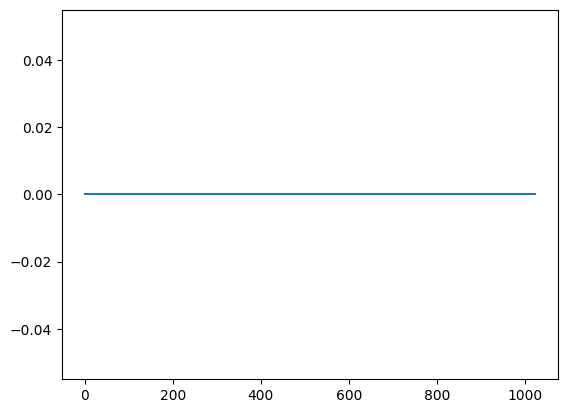

In [62]:
plt.plot(output[16,30])

In [49]:
import pickle

In [19]:
ints[g_loc]/np.max(ints)-ints[red_loc]/np.max(ints)<.1

np.True_

In [17]:
## save param_dict
import pickle
def unPickle(filename):
    '''
    to shorten 3 lines into 1 line
    '''
    with open(filename,'rb') as f:
        output = pickle.load(f)
    f.close()
    return output

def makePickle(filename,data):
    with open(filename,'wb') as f:
        pickle.dump(data,f)
    f.close()

## use different integration time at a certain elevation
### this can be automized (e.g. take a quick vertical line scan, find the drop-> vertical line)

In [18]:
## quick test in Feb2025

In [19]:
h_left = 30
h_right = -30
stepsize_h = 2

h_steps = (np.abs(h_left)+np.abs(h_right))//stepsize_h

v_top = 25
v_threshold = -20
v_down = -25
stepsize_top=2
stepsize_down=2
v_steps = np.abs(v_top-v_threshold)//stepsize_top+np.abs(v_threshold-v_down)//stepsize_down


micro_time_top = 1.0*1e6
micro_time_down = 1.0*1e6
top_dark_ = np.load(f'../../telescope/data/darkNoise/darkNoise_{micro_time_top/1e3}ms.npy')
down_dark_ = np.load(f'../../telescope/data/darkNoise/darkNoise_{micro_time_down/1e3}ms.npy')

In [21]:
# Create dictionary
params_dict = {
    "h_left": h_left,
    "h_right": h_right,
    "stepsize_h": stepsize_h,
    "h_steps": int(h_steps),  # Convert to int for clean output

    "v_top": v_top,
    "v_threshold": v_threshold,
    "v_down": v_down,
    "stepsize_top": stepsize_top,
    "stepsize_down": stepsize_down,
    "v_steps": int(v_steps),  # Convert to int for clean output

    "micro_time_top": micro_time_top,
    "micro_time_down": micro_time_down,
    "top_dark_":top_dark_,
    "down_dark_":down_dark_,
    'weather':'inside',
    'cmt':'testing cam-scanner sync'
}

In [22]:
output = np.zeros((v_steps+1,h_steps+1,1024))
print(output.shape)

(21, 31, 1024)


In [23]:
move_to_esp32(0,0)

ESP32 Response: Moved to PAN=0, TILT=0


In [24]:
import datetime
print(datetime.datetime.now())

2025-02-26 16:24:38.590492


In [25]:
start_t = str(datetime.datetime.now())[:19].replace('-','_').replace(':','_').replace(' ','_')
params_dict['start_t'] = start_t

In [ ]:
print('start at: ',datetime.datetime.now())
params_dict['scan_pattern']='ul_ll_ur_lr'
for hh,pan_ in enumerate(range(h_left,h_right,-stepsize_h)):
    for vv,tilt_ in enumerate(range(v_top,v_down,-stepsize_top)):
        move_to_esp32(pan_,tilt_)
        if tilt_>v_threshold:
            spec.integration_time_micros(micro_time_top)
        else:
            spec.integration_time_micros(micro_time_down)
        time.sleep(.5)
        _,output[vv,hh] = spec.spectrum()
print('finished at: ',datetime.datetime.now())

In [28]:
end_t = str(datetime.datetime.now())[:19].replace('-','_').replace(':','_').replace(' ','_')
params_dict['raw_record'] = output
params_dict['end_t'] = end_t
makePickle(f'{end_t}.pkl',params_dict)